In [2]:
%pip install pandas pytest

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 1.7 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.8 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.8 MB 2.0 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.8 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.8 MB 1.9 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.8 MB 1.8 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.8 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.4/9.8 MB 1.9 MB/s eta 0:00:04
   -------------- ------------------------- 3.7/9.8 MB 1.9 MB/s eta 0:00:04
   --------------- ------------------------ 3.9/9.8 MB 1.9 MB/s eta 0:00:04
   ------------------ --

In [3]:
from pathlib import Path
import sys
import json
import time
from collections import defaultdict

import pandas as pd

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pkb_math import (
    DEFAULT_SHRINKAGE,
    conservative_noisy_or,
    conflict_adjusted_confidence,
    final_confidence,
    max_merge,
    mean_aggregation,
    standard_noisy_or,
)

data_path = project_root / "data" / "dec003_controlled_observations.jsonl"
policy_path = project_root / "configs" / "dec003_functional_predicates.json"
output_dir = project_root / "outputs" / "dec003_pkb_validation"
output_dir.mkdir(parents=True, exist_ok=True)

with data_path.open("r", encoding="utf-8") as f:
    observations = [json.loads(line) for line in f if line.strip()]

with policy_path.open("r", encoding="utf-8") as f:
    predicate_policy = json.load(f)

functional_predicates = set(predicate_policy["functional_predicates"])

print("Project root:", project_root)
print("Observations loaded:", len(observations))
print("Functional predicates:", sorted(functional_predicates))
print("Shrinkage lambda:", DEFAULT_SHRINKAGE)

Project root: e:\slde-aft
Observations loaded: 18
Functional predicates: ['belongs_to_category', 'has_color', 'has_noise_cancellation', 'has_price_usd', 'target_market_region']
Shrinkage lambda: 0.75


In [4]:
observations_df = pd.DataFrame(observations)

display(
    observations_df[
        [
            "iteration",
            "subject",
            "predicate",
            "object",
            "confidence",
            "source_id",
            "source_type",
            "gold_label",
        ]
    ].sort_values(
        ["subject", "predicate", "object", "iteration"]
    )
)

,iteration,subject,predicate,object,confidence,source_id,source_type,gold_label
0,1,Product-A,has_color,black,0.90,structured_001,structured,1
1,2,Product-A,has_color,black,0.85,unstructured_001,unstructured,1
2,3,Product-A,has_color,black,0.80,unstructured_002,unstructured,1
3,1,Product-A,has_color,white,0.70,unstructured_003,unstructured,0
4,3,Product-A,has_color,white,0.60,unstructured_004,unstructured,0
7,1,Product-A,has_noise_cancellation,no,0.55,unstructured_006,unstructured,0
5,1,Product-A,has_noise_cancellation,yes,0.88,structured_002,structured,1
6,2,Product-A,has_noise_cancellation,yes,0.82,unstructured_005,unstructured,1
8,1,Product-B,belongs_to_category,laptop,0.92,structured_003,structured,1
9,2,Product-B,belongs_to_category,laptop,0.75,unstructured_007,unstructured,1


In [5]:
triple_groups = defaultdict(list)

for observation in observations:
    triple_key = (
        observation["subject"],
        observation["predicate"],
        observation["object"],
    )
    triple_groups[triple_key].append(observation)

print("Unique triples:", len(triple_groups))

for triple_key, group in sorted(triple_groups.items()):
    confidences = [item["confidence"] for item in group]
    gold_label = group[0]["gold_label"]

    print(
        f"{triple_key} | "
        f"observations={len(group)} | "
        f"confidences={confidences} | "
        f"gold_label={gold_label}"
    )

Unique triples: 10
('Product-A', 'has_color', 'black') | observations=3 | confidences=[0.9, 0.85, 0.8] | gold_label=1
('Product-A', 'has_color', 'white') | observations=2 | confidences=[0.7, 0.6] | gold_label=0
('Product-A', 'has_noise_cancellation', 'no') | observations=1 | confidences=[0.55] | gold_label=0
('Product-A', 'has_noise_cancellation', 'yes') | observations=2 | confidences=[0.88, 0.82] | gold_label=1
('Product-B', 'belongs_to_category', 'laptop') | observations=2 | confidences=[0.92, 0.75] | gold_label=1
('Product-B', 'belongs_to_category', 'tablet') | observations=1 | confidences=[0.65] | gold_label=0
('Product-C', 'made_of_material', 'aluminum') | observations=2 | confidences=[0.89, 0.78] | gold_label=1
('Product-D', 'has_price_usd', '499') | observations=2 | confidences=[0.94, 0.86] | gold_label=1
('Product-D', 'has_price_usd', '549') | observations=1 | confidences=[0.72] | gold_label=0
('Product-E', 'target_market_region', 'EU') | observations=2 | confidences=[0.84, 0.7

In [6]:
objects_by_subject_predicate = defaultdict(set)

for subject, predicate, obj in triple_groups:
    objects_by_subject_predicate[(subject, predicate)].add(obj)

competitor_counts = {}

for subject, predicate, obj in triple_groups:
    candidate_objects = objects_by_subject_predicate[(subject, predicate)]

    if predicate in functional_predicates:
        competitor_counts[(subject, predicate, obj)] = len(candidate_objects - {obj})
    else:
        competitor_counts[(subject, predicate, obj)] = 0

for triple_key in sorted(competitor_counts):
    subject, predicate, obj = triple_key

    print(
        f"{triple_key} | "
        f"functional={predicate in functional_predicates} | "
        f"competitors={competitor_counts[triple_key]}"
    )

('Product-A', 'has_color', 'black') | functional=True | competitors=1
('Product-A', 'has_color', 'white') | functional=True | competitors=1
('Product-A', 'has_noise_cancellation', 'no') | functional=True | competitors=1
('Product-A', 'has_noise_cancellation', 'yes') | functional=True | competitors=1
('Product-B', 'belongs_to_category', 'laptop') | functional=True | competitors=1
('Product-B', 'belongs_to_category', 'tablet') | functional=True | competitors=1
('Product-C', 'made_of_material', 'aluminum') | functional=False | competitors=0
('Product-D', 'has_price_usd', '499') | functional=True | competitors=1
('Product-D', 'has_price_usd', '549') | functional=True | competitors=1
('Product-E', 'target_market_region', 'EU') | functional=True | competitors=0


In [7]:
score_rows = []

for triple_key, group in sorted(triple_groups.items()):
    subject, predicate, obj = triple_key

    confidences = [item["confidence"] for item in group]
    iterations = [item["iteration"] for item in group]
    source_ids = [item["source_id"] for item in group]
    source_types = [item["source_type"] for item in group]

    is_functional = predicate in functional_predicates
    competitor_count = competitor_counts[triple_key]

    start = time.perf_counter()

    max_score = max_merge(confidences)
    mean_score = mean_aggregation(confidences)
    standard_noisy_or_score = standard_noisy_or(confidences)
    conservative_support = conservative_noisy_or(
        confidences,
        shrinkage=DEFAULT_SHRINKAGE,
    )
    conservative_conflict_score = final_confidence(
        confidences=confidences,
        competitor_count=competitor_count,
        shrinkage=DEFAULT_SHRINKAGE,
        functional_predicate=is_functional,
    )

    elapsed = time.perf_counter() - start

    score_rows.append({
        "subject": subject,
        "predicate": predicate,
        "object": obj,
        "gold_label": group[0]["gold_label"],
        "observation_count": len(group),
        "confidences": json.dumps(confidences),
        "first_iteration": min(iterations),
        "last_iteration": max(iterations),
        "source_count": len(set(source_ids)),
        "source_types": " | ".join(sorted(set(source_types))),
        "functional_predicate": is_functional,
        "competitor_count": competitor_count,
        "max_merge": max_score,
        "mean_aggregation": mean_score,
        "standard_noisy_or": standard_noisy_or_score,
        "conservative_noisy_or": conservative_support,
        "conservative_noisy_or_conflict_adjusted": conservative_conflict_score,
        "calculation_seconds": elapsed,
    })

per_triple_scores_df = pd.DataFrame(score_rows)

display(
    per_triple_scores_df[
        [
            "subject",
            "predicate",
            "object",
            "gold_label",
            "observation_count",
            "functional_predicate",
            "competitor_count",
            "max_merge",
            "mean_aggregation",
            "standard_noisy_or",
            "conservative_noisy_or",
            "conservative_noisy_or_conflict_adjusted",
        ]
    ].round(4)
)

,subject,predicate,object,gold_label,observation_count,functional_predicate,competitor_count,max_merge,mean_aggregation,standard_noisy_or,conservative_noisy_or,conservative_noisy_or_conflict_adjusted
0,Product-A,has_color,black,1,3,True,1,0.90,0.850,0.9970,0.9529,0.4764
1,Product-A,has_color,white,0,2,True,1,0.70,0.650,0.8800,0.7387,0.3694
2,Product-A,has_noise_cancellation,no,0,1,True,1,0.55,0.550,0.5500,0.4125,0.2063
3,Product-A,has_noise_cancellation,yes,1,2,True,1,0.88,0.850,0.9784,0.8691,0.4346
4,Product-B,belongs_to_category,laptop,1,2,True,1,0.92,0.835,0.9800,0.8644,0.4322
5,Product-B,belongs_to_category,tablet,0,1,True,1,0.65,0.650,0.6500,0.4875,0.2438
6,Product-C,made_of_material,aluminum,1,2,False,0,0.89,0.835,0.9758,0.8620,0.8620
7,Product-D,has_price_usd,499,1,2,True,1,0.94,0.900,0.9916,0.8953,0.4476
8,Product-D,has_price_usd,549,0,1,True,1,0.72,0.720,0.7200,0.5400,0.2700
9,Product-E,target_market_region,EU,1,2,True,0,0.84,0.800,0.9616,0.8409,0.8409


In [8]:
per_triple_path = output_dir / "per_triple_scores.csv"

per_triple_scores_df.to_csv(
    per_triple_path,
    index=False,
    encoding="utf-8",
)

print("Saved per-triple scores to:", per_triple_path)
print("Rows saved:", len(per_triple_scores_df))

Saved per-triple scores to: e:\slde-aft\outputs\dec003_pkb_validation\per_triple_scores.csv
Rows saved: 10


In [10]:
black_row = per_triple_scores_df[
    (per_triple_scores_df["subject"] == "Product-A")
    & (per_triple_scores_df["predicate"] == "has_color")
    & (per_triple_scores_df["object"] == "black")
].iloc[0]

material_row = per_triple_scores_df[
    (per_triple_scores_df["subject"] == "Product-C")
    & (per_triple_scores_df["predicate"] == "made_of_material")
    & (per_triple_scores_df["object"] == "aluminum")
].iloc[0]

score_columns = [
    "max_merge",
    "mean_aggregation",
    "standard_noisy_or",
    "conservative_noisy_or",
    "conservative_noisy_or_conflict_adjusted",
]

material_scores_equal = abs(
    material_row["conservative_noisy_or"]
    - material_row["conservative_noisy_or_conflict_adjusted"]
) < 1e-12

all_scores_bounded = bool(
    per_triple_scores_df[score_columns]
    .apply(lambda column: column.between(0.0, 1.0).all())
    .all()
)

print("Verification checks")
print("-" * 70)

print(
    "Black triple conflict ratio:",
    round(
        black_row["conservative_noisy_or_conflict_adjusted"]
        / black_row["conservative_noisy_or"],
        4,
    ),
)

print(
    "Material support equals final score:",
    material_scores_equal,
)

print(
    "All scores within [0, 1]:",
    all_scores_bounded,
)

Verification checks
----------------------------------------------------------------------
Black triple conflict ratio: 0.5
Material support equals final score: True
All scores within [0, 1]: True


In [11]:
print(
    "Material support equals final score:",
    material_row["conservative_noisy_or"]
    == material_row["conservative_noisy_or_conflict_adjusted"],
)

Material support equals final score: True


In [12]:
thresholds = [0.20, 0.40, 0.60, 0.80, 0.85, 0.88, 0.90, 0.95]

In [13]:
def precision_recall_f1_from_labels(labels):
    true_positives = sum(labels)
    false_positives = len(labels) - true_positives

    total_gold_positives = int(per_triple_scores_df["gold_label"].sum())
    false_negatives = total_gold_positives - true_positives

    precision = (
        true_positives / (true_positives + false_positives)
        if (true_positives + false_positives) > 0
        else 0.0
    )

    recall = (
        true_positives / (true_positives + false_negatives)
        if (true_positives + false_negatives) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [14]:
methods = {
    "max_merge": "max_merge",
    "mean_aggregation": "mean_aggregation",
    "standard_noisy_or": "standard_noisy_or",
    "conservative_noisy_or": "conservative_noisy_or",
    "conservative_noisy_or_conflict_adjusted": (
        "conservative_noisy_or_conflict_adjusted"
    ),
}

thresholds = [0.20, 0.40, 0.60, 0.80, 0.85, 0.88, 0.90, 0.95]

threshold_rows = []

for method_name, score_column in methods.items():
    for threshold in thresholds:
        retained = per_triple_scores_df[
            per_triple_scores_df[score_column] >= threshold
        ].copy()

        labels = retained["gold_label"].tolist()
        metric_values = precision_recall_f1_from_labels(labels)

        threshold_rows.append({
            "method": method_name,
            "score_column": score_column,
            "threshold": threshold,
            "retained_triple_count": len(retained),
            "conflict_count": int(
                retained["competitor_count"].gt(0).sum()
            ),
            **metric_values,
        })

threshold_sweep_df = pd.DataFrame(threshold_rows)

display(
    threshold_sweep_df[
        [
            "method",
            "threshold",
            "retained_triple_count",
            "true_positives",
            "false_positives",
            "false_negatives",
            "precision",
            "recall",
            "f1",
            "conflict_count",
        ]
    ].round(4)
)

,method,threshold,retained_triple_count,true_positives,false_positives,false_negatives,precision,recall,f1,conflict_count
0,max_merge,0.20,10,6,4,0,0.6000,1.0000,0.7500,8
1,max_merge,0.40,10,6,4,0,0.6000,1.0000,0.7500,8
2,max_merge,0.60,9,6,3,0,0.6667,1.0000,0.8000,7
3,max_merge,0.80,6,6,0,0,1.0000,1.0000,1.0000,4
4,max_merge,0.85,5,5,0,1,1.0000,0.8333,0.9091,4
5,max_merge,0.88,5,5,0,1,1.0000,0.8333,0.9091,4
6,max_merge,0.90,3,3,0,3,1.0000,0.5000,0.6667,3
7,max_merge,0.95,0,0,0,6,0.0000,0.0000,0.0000,0
8,mean_aggregation,0.20,10,6,4,0,0.6000,1.0000,0.7500,8
9,mean_aggregation,0.40,10,6,4,0,0.6000,1.0000,0.7500,8


In [15]:
threshold_path = output_dir / "threshold_sweep.csv"

threshold_sweep_df.to_csv(
    threshold_path,
    index=False,
    encoding="utf-8",
)

print("Saved threshold sweep to:", threshold_path)
print("Rows saved:", len(threshold_sweep_df))

Saved threshold sweep to: e:\slde-aft\outputs\dec003_pkb_validation\threshold_sweep.csv
Rows saved: 40


In [16]:
threshold_088 = threshold_sweep_df[
    threshold_sweep_df["threshold"] == 0.88
].copy()

display_cols = [
    "method",
    "threshold",
    "retained_triple_count",
    "true_positives",
    "false_positives",
    "false_negatives",
    "precision",
    "recall",
    "f1",
    "conflict_count",
]

display(
    threshold_088[display_cols].round(4)
)

,method,threshold,retained_triple_count,true_positives,false_positives,false_negatives,precision,recall,f1,conflict_count
5,max_merge,0.88,5,5,0,1,1.0000,0.8333,0.9091,4
13,mean_aggregation,0.88,1,1,0,5,1.0000,0.1667,0.2857,1
21,standard_noisy_or,0.88,7,6,1,0,0.8571,1.0000,0.9231,5
29,conservative_noisy_or,0.88,2,2,0,4,1.0000,0.3333,0.5000,2
37,conservative_noisy_or_conflict_adjusted,0.88,0,0,0,6,0.0000,0.0000,0.0000,0


In [17]:
import numpy as np

calib_bins = np.linspace(0.0, 1.0, 11)  # [0.0, 0.1, ..., 1.0]

def add_calibration_bin(df, score_column, bin_column_name):
    df = df.copy()
    df[bin_column_name] = pd.cut(
        df[score_column],
        bins=calib_bins,
        labels=calib_bins[:-1],
        include_lowest=True,
        right=False,
    ).astype(str)
    return df

calib_df = per_triple_scores_df.copy()

for method_name, score_column in methods.items():
    calib_df = add_calibration_bin(
        calib_df,
        score_column,
        f"calib_bin_{method_name}",
    )

def compute_ece_for_method(df, score_column, bin_column_name):
    ece = 0.0
    total = len(df)

    for bin_label in df[bin_column_name].unique():
        mask = df[bin_column_name] == bin_label
        bin_df = df[mask]
        n_b = len(bin_df)

        if n_b == 0:
            continue

        avg_confidence = bin_df[score_column].mean()
        avg_accuracy = bin_df["gold_label"].mean()

        ece += (n_b / total) * abs(avg_accuracy - avg_confidence)

    return ece

ece_rows = []

for method_name, score_column in methods.items():
    bin_col = f"calib_bin_{method_name}"
    ece_val = compute_ece_for_method(calib_df, score_column, bin_col)

    ece_rows.append({
        "method": method_name,
        "score_column": score_column,
        "ece": ece_val,
    })

ece_df = pd.DataFrame(ece_rows)

display(
    ece_df.round(6)
)

,method,score_column,ece
0,max_merge,max_merge,0.325000
1,mean_aggregation,mean_aggregation,0.350000
2,standard_noisy_or,standard_noisy_or,0.291560
3,conservative_noisy_or,conservative_noisy_or,0.289421
4,conservative_noisy_or_conflict_adjusted,conservative_noisy_or_conflict_adjusted,0.359565


In [18]:
ece_path = output_dir / "ece_by_method.csv"

ece_df.to_csv(
    ece_path,
    index=False,
    encoding="utf-8",
)

print("Saved ECE by method to:", ece_path)
print("Rows saved:", len(ece_df))

Saved ECE by method to: e:\slde-aft\outputs\dec003_pkb_validation\ece_by_method.csv
Rows saved: 5


In [19]:
calibration_rows = []

for method_name, score_column in methods.items():
    for bin_index in range(len(calib_bins) - 1):
        lower = float(calib_bins[bin_index])
        upper = float(calib_bins[bin_index + 1])

        if bin_index == len(calib_bins) - 2:
            mask = (
                (calib_df[score_column] >= lower)
                & (calib_df[score_column] <= upper)
            )
        else:
            mask = (
                (calib_df[score_column] >= lower)
                & (calib_df[score_column] < upper)
            )

        bin_df = calib_df[mask]
        count = len(bin_df)

        if count == 0:
            mean_confidence = np.nan
            empirical_accuracy = np.nan
            calibration_gap = np.nan
            weighted_gap = 0.0
        else:
            mean_confidence = float(bin_df[score_column].mean())
            empirical_accuracy = float(bin_df["gold_label"].mean())
            calibration_gap = abs(empirical_accuracy - mean_confidence)
            weighted_gap = (count / len(calib_df)) * calibration_gap

        calibration_rows.append({
            "method": method_name,
            "score_column": score_column,
            "bin_lower": lower,
            "bin_upper": upper,
            "count": count,
            "mean_confidence": mean_confidence,
            "empirical_accuracy": empirical_accuracy,
            "calibration_gap": calibration_gap,
            "weighted_gap": weighted_gap,
        })

calibration_bins_df = pd.DataFrame(calibration_rows)

display(
    calibration_bins_df[
        calibration_bins_df["count"] > 0
    ].round(6)
)

,method,score_column,bin_lower,bin_upper,count,mean_confidence,empirical_accuracy,calibration_gap,weighted_gap
5,max_merge,max_merge,0.5,0.6,1,0.550000,0.0,0.550000,0.055000
6,max_merge,max_merge,0.6,0.7,2,0.675000,0.0,0.675000,0.135000
7,max_merge,max_merge,0.7,0.8,1,0.720000,0.0,0.720000,0.072000
8,max_merge,max_merge,0.8,0.9,3,0.870000,1.0,0.130000,0.039000
9,max_merge,max_merge,0.9,1.0,3,0.920000,1.0,0.080000,0.024000
15,mean_aggregation,mean_aggregation,0.5,0.6,1,0.550000,0.0,0.550000,0.055000
16,mean_aggregation,mean_aggregation,0.6,0.7,2,0.650000,0.0,0.650000,0.130000
17,mean_aggregation,mean_aggregation,0.7,0.8,1,0.720000,0.0,0.720000,0.072000
18,mean_aggregation,mean_aggregation,0.8,0.9,6,0.845000,1.0,0.155000,0.093000
25,standard_noisy_or,standard_noisy_or,0.5,0.6,1,0.550000,0.0,0.550000,0.055000


In [20]:
calibration_bins_path = output_dir / "calibration_bins.csv"

calibration_bins_df.to_csv(
    calibration_bins_path,
    index=False,
    encoding="utf-8",
)

print("Saved calibration bins to:", calibration_bins_path)
print("Rows saved:", len(calibration_bins_df))

Saved calibration bins to: e:\slde-aft\outputs\dec003_pkb_validation\calibration_bins.csv
Rows saved: 50


In [21]:
brier_rows = []

for method_name, score_column in methods.items():
    brier_score = float(
        (
            per_triple_scores_df[score_column]
            - per_triple_scores_df["gold_label"]
        )
        .pow(2)
        .mean()
    )

    brier_rows.append({
        "method": method_name,
        "score_column": score_column,
        "brier_score": brier_score,
    })

brier_df = pd.DataFrame(brier_rows)

display(brier_df.round(6))

,method,score_column,brier_score
0,max_merge,max_merge,0.180550
1,mean_aggregation,mean_aggregation,0.181535
2,standard_noisy_or,standard_noisy_or,0.202081
3,conservative_noisy_or,conservative_noisy_or,0.133823
4,conservative_noisy_or_conflict_adjusted,conservative_noisy_or_conflict_adjusted,0.157701


In [22]:
brier_path = output_dir / "brier_by_method.csv"

brier_df.to_csv(
    brier_path,
    index=False,
    encoding="utf-8",
)

print("Saved Brier scores to:", brier_path)
print("Rows saved:", len(brier_df))

Saved Brier scores to: e:\slde-aft\outputs\dec003_pkb_validation\brier_by_method.csv
Rows saved: 5


In [24]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.3 MB 3.5 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.3 MB 3.1 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 3.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.1 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 3.1 MB/s eta 0:00:02
   ------------------------- -----------

Matplotlib is building the font cache; this may take a moment.


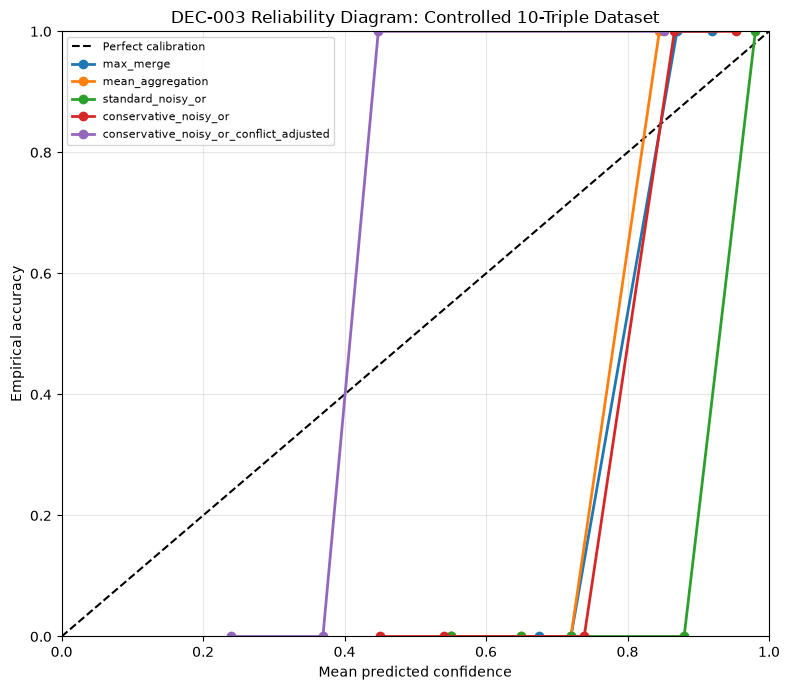

Saved reliability diagram to: e:\slde-aft\outputs\dec003_pkb_validation\reliability_diagram.png


In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

plt.plot(
    [0.0, 1.0],
    [0.0, 1.0],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Perfect calibration",
)

for method_name, score_column in methods.items():
    method_bins = calibration_bins_df[
        (calibration_bins_df["method"] == method_name)
        & (calibration_bins_df["count"] > 0)
    ].copy()

    plt.plot(
        method_bins["mean_confidence"],
        method_bins["empirical_accuracy"],
        marker="o",
        linewidth=2,
        label=method_name,
    )

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.xlabel("Mean predicted confidence")
plt.ylabel("Empirical accuracy")
plt.title("DEC-003 Reliability Diagram: Controlled 10-Triple Dataset")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc="best")
plt.tight_layout()

reliability_path = output_dir / "reliability_diagram.png"

plt.savefig(
    reliability_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved reliability diagram to:", reliability_path)

In [26]:
required_thresholds = [0.80, 0.85, 0.88, 0.90, 0.95]

required_threshold_results_df = threshold_sweep_df[
    threshold_sweep_df["threshold"].isin(required_thresholds)
].copy()

required_threshold_results_df = required_threshold_results_df[
    [
        "method",
        "threshold",
        "retained_triple_count",
        "true_positives",
        "false_positives",
        "false_negatives",
        "precision",
        "recall",
        "f1",
        "conflict_count",
    ]
].sort_values(
    ["method", "threshold"]
)

display(required_threshold_results_df.round(4))

,method,threshold,retained_triple_count,true_positives,false_positives,false_negatives,precision,recall,f1,conflict_count
27,conservative_noisy_or,0.80,6,6,0,0,1.0000,1.0000,1.0000,4
28,conservative_noisy_or,0.85,5,5,0,1,1.0000,0.8333,0.9091,4
29,conservative_noisy_or,0.88,2,2,0,4,1.0000,0.3333,0.5000,2
30,conservative_noisy_or,0.90,1,1,0,5,1.0000,0.1667,0.2857,1
31,conservative_noisy_or,0.95,1,1,0,5,1.0000,0.1667,0.2857,1
35,conservative_noisy_or_conflict_adjusted,0.80,2,2,0,4,1.0000,0.3333,0.5000,0
36,conservative_noisy_or_conflict_adjusted,0.85,1,1,0,5,1.0000,0.1667,0.2857,0
37,conservative_noisy_or_conflict_adjusted,0.88,0,0,0,6,0.0000,0.0000,0.0000,0
38,conservative_noisy_or_conflict_adjusted,0.90,0,0,0,6,0.0000,0.0000,0.0000,0
39,conservative_noisy_or_conflict_adjusted,0.95,0,0,0,6,0.0000,0.0000,0.0000,0


In [27]:
required_threshold_path = output_dir / "required_thresholds_summary.csv"

required_threshold_results_df.to_csv(
    required_threshold_path,
    index=False,
    encoding="utf-8",
)

print("Saved required threshold summary to:", required_threshold_path)
print("Rows saved:", len(required_threshold_results_df))

Saved required threshold summary to: e:\slde-aft\outputs\dec003_pkb_validation\required_thresholds_summary.csv
Rows saved: 25


In [28]:
best_threshold_rows = []

for method_name in methods:
    method_results = threshold_sweep_df[
        threshold_sweep_df["method"] == method_name
    ].copy()

    best_row = method_results.loc[
        method_results["f1"].idxmax()
    ]

    best_threshold_rows.append({
        "method": method_name,
        "best_threshold_by_toy_f1": best_row["threshold"],
        "best_precision": best_row["precision"],
        "best_recall": best_row["recall"],
        "best_f1": best_row["f1"],
        "retained_triple_count": best_row["retained_triple_count"],
        "conflict_count": best_row["conflict_count"],
    })

best_thresholds_df = pd.DataFrame(best_threshold_rows)

display(best_thresholds_df.round(4))

,method,best_threshold_by_toy_f1,best_precision,best_recall,best_f1,retained_triple_count,conflict_count
0,max_merge,0.8,1.0,1.0,1.0,6,4
1,mean_aggregation,0.8,1.0,1.0,1.0,6,4
2,standard_noisy_or,0.9,1.0,1.0,1.0,6,4
3,conservative_noisy_or,0.8,1.0,1.0,1.0,6,4
4,conservative_noisy_or_conflict_adjusted,0.4,1.0,1.0,1.0,6,4


In [29]:
best_thresholds_path = output_dir / "best_thresholds_toy.csv"

best_thresholds_df.to_csv(
    best_thresholds_path,
    index=False,
    encoding="utf-8",
)

print("Saved toy best-threshold summary to:", best_thresholds_path)
print("Rows saved:", len(best_thresholds_df))

Saved toy best-threshold summary to: e:\slde-aft\outputs\dec003_pkb_validation\best_thresholds_toy.csv
Rows saved: 5


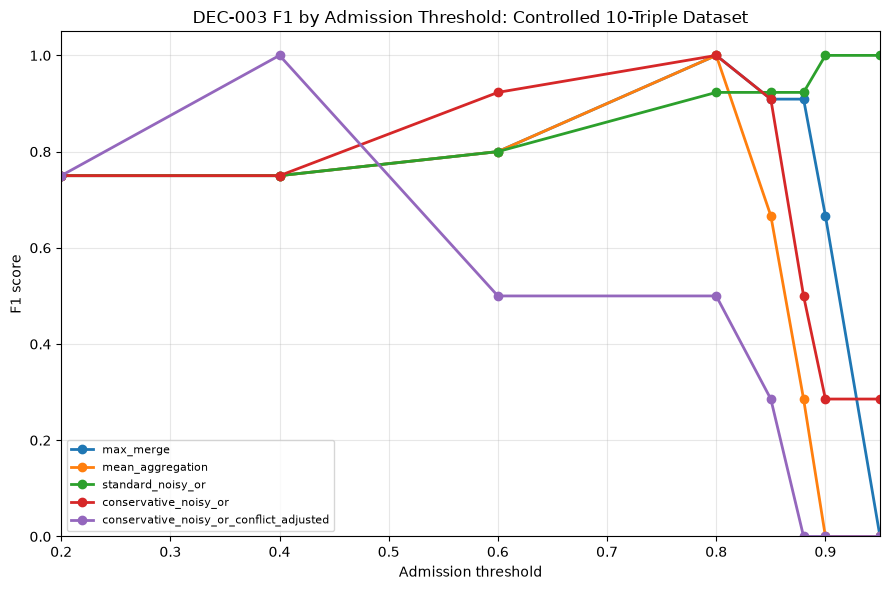

Saved F1-by-threshold plot to: e:\slde-aft\outputs\dec003_pkb_validation\f1_by_threshold.png


In [30]:
plt.figure(figsize=(9, 6))

for method_name in methods:
    method_results = threshold_sweep_df[
        threshold_sweep_df["method"] == method_name
    ].sort_values("threshold")

    plt.plot(
        method_results["threshold"],
        method_results["f1"],
        marker="o",
        linewidth=2,
        label=method_name,
    )

plt.xlabel("Admission threshold")
plt.ylabel("F1 score")
plt.title("DEC-003 F1 by Admission Threshold: Controlled 10-Triple Dataset")
plt.xlim(min(threshold_sweep_df["threshold"]), max(threshold_sweep_df["threshold"]))
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc="best")
plt.tight_layout()

f1_threshold_path = output_dir / "f1_by_threshold.png"

plt.savefig(
    f1_threshold_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved F1-by-threshold plot to:", f1_threshold_path)